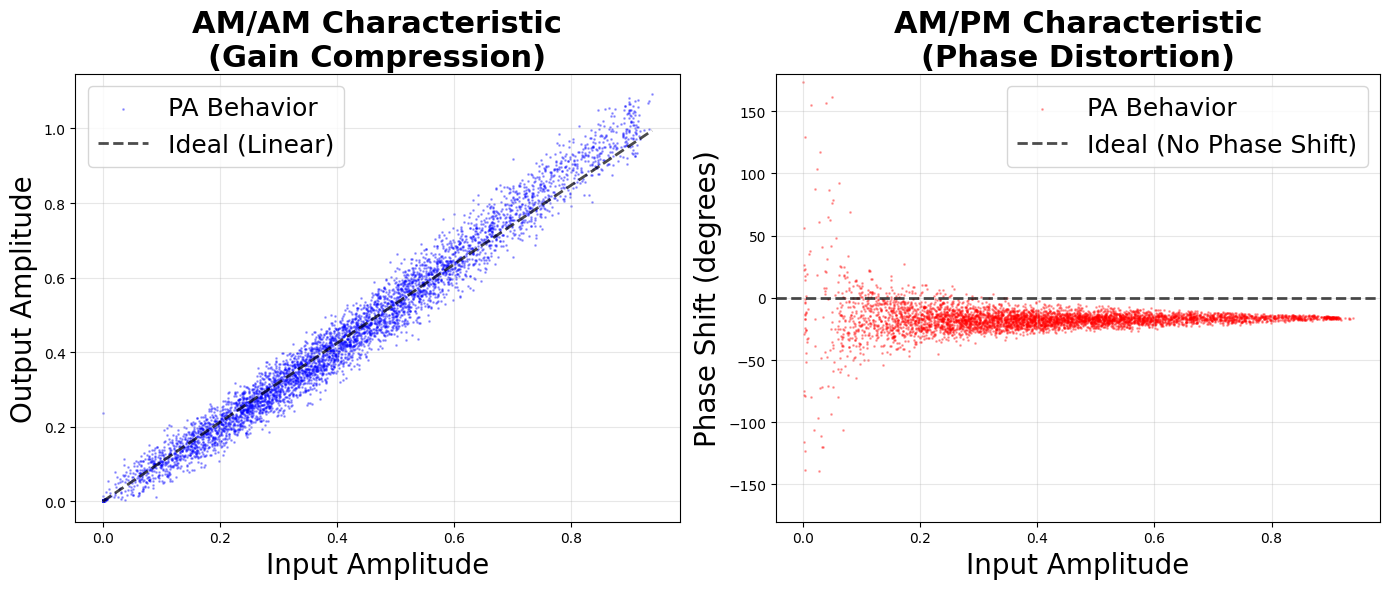


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9384
Output amplitude range: 0.0003 to 1.0917
Estimated small-signal gain: 1.0596
Phase distortion range: -139.61° to 1039.85°
80000


In [6]:
from sparseDPD import DataManager, PNTDNN_NeuralNetwork, Volterra, LinearExperiment, AdaptivePruningExperiment

# Load the ideal predistorted signal, and plot
ideal_predistored_dataset = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='200M_6_5PAPR.mat')

ideal_predistored_dataset.plot_pa_characteristics()

print(len(ideal_predistored_dataset.input_data))

In [7]:
# Print Volterra Performance
volterra_forward_model = Volterra(num_nl_orders=3, num_memory_levels=15, dataset=ideal_predistored_dataset.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(ideal_predistored_dataset.test_dataset)} dB")

 Volterra NMSE: -36.78570189648688 dB


In [8]:
# Model the ideal predistorted (This will actually be modelled as a forward model)
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True)

# train this model
pntdnn_ideal_predistorted.get_best_model(
    num_epochs = 500,
    training_dataset=ideal_predistored_dataset.training_dataset,
    validation_dataset=ideal_predistored_dataset.validation_dataset
)

# Save the model, so it can be used later
pntdnn_ideal_predistorted.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model.pt")


Using cuda device
Epoch  10/500  Loss=1.0318e+03  Valid Loss=9.5914e+01  LR=1.00e-03  NMSE=-8.3198 dB
Epoch  20/500  Loss=1.9994e+02  Valid Loss=1.7758e+01  LR=1.00e-03  NMSE=-15.6448 dB
Epoch  30/500  Loss=6.0388e+01  Valid Loss=5.3651e+00  LR=1.00e-03  NMSE=-20.8429 dB
Epoch  40/500  Loss=2.8056e+01  Valid Loss=2.5761e+00  LR=1.00e-03  NMSE=-24.0291 dB
Epoch  50/500  Loss=1.9045e+01  Valid Loss=1.7580e+00  LR=1.00e-03  NMSE=-25.6885 dB
Epoch  60/500  Loss=1.3991e+01  Valid Loss=1.2969e+00  LR=1.00e-03  NMSE=-27.0096 dB
Epoch  70/500  Loss=1.0601e+01  Valid Loss=9.8970e-01  LR=1.00e-03  NMSE=-28.1836 dB
Epoch  80/500  Loss=8.1789e+00  Valid Loss=7.7057e-01  LR=1.00e-03  NMSE=-29.2705 dB
Epoch  90/500  Loss=6.4284e+00  Valid Loss=6.1079e-01  LR=1.00e-03  NMSE=-30.2797 dB
Epoch 100/500  Loss=5.1819e+00  Valid Loss=4.9560e-01  LR=1.00e-03  NMSE=-31.1873 dB
Epoch 110/500  Loss=4.3029e+00  Valid Loss=4.1669e-01  LR=1.00e-03  NMSE=-31.9405 dB
Epoch 120/500  Loss=3.6764e+00  Valid Loss=3.640

Using cuda device

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=1.1821e+00  Valid Loss=1.1856e-01  LR=1.00e-03  NMSE=-37.3991 dB
Epoch  20/100  Loss=9.0780e-01  Valid Loss=8.8346e-02  LR=1.00e-03  NMSE=-38.6768 dB
Epoch  30/100  Loss=8.5538e-01  Valid Loss=8.0504e-02  LR=1.00e-03  NMSE=-39.0805 dB
Epoch  40/100  Loss=8.4860e-01  Valid Loss=7.8422e-02  LR=1.00e-03  NMSE=-39.1943 dB
Epoch  50/100  Loss=8.2859e-01  Valid Loss=7.6382e-02  LR=1.00e-03  NMSE=-39.3087 dB
Epoch  60/100  Loss=8.1242e-01  Valid Loss=7.4871e-02  LR=1.00e-03  NMSE=-39.3955 dB
Epoch  70/100  Loss=7.9884e-01  Valid Loss=7.3523e-02  LR=1.00e-03  NMSE=-39.4745 dB
Epoch  80/100  Loss=7.8774e-01  Valid Loss=7.2465e-02  LR=1.00e-03  NMSE=-39.5374 dB
Epoch  90/100  Loss=7.7808e-01  Valid Loss=7.1479e-02  LR=1.00e-03  NMSE=-39.5969 dB
Epoch 100/100  Loss=7.6959e-01  Valid Loss=7.0588e-02  LR=1.00e-03  NMSE=-39.6514 

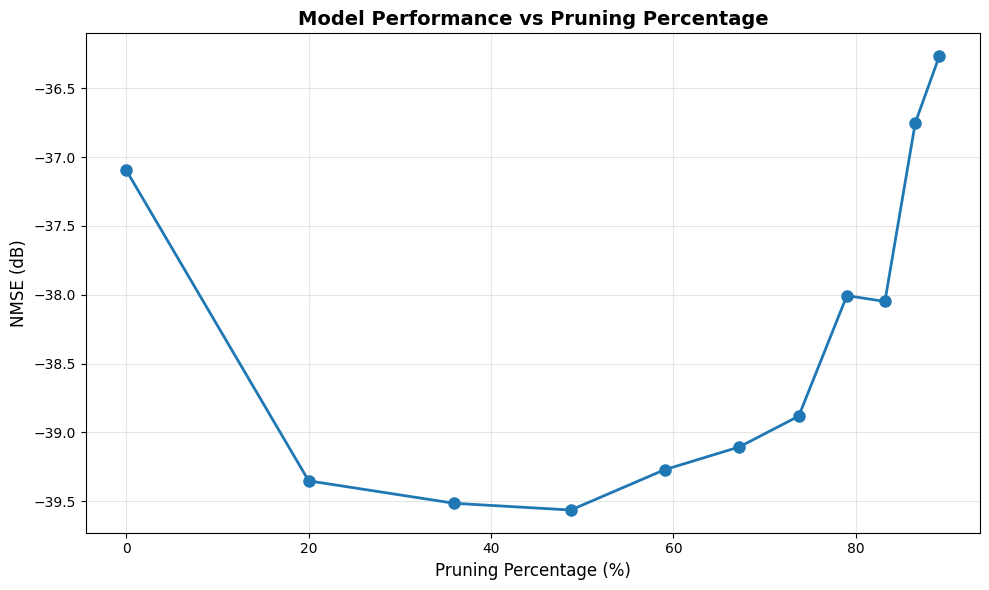

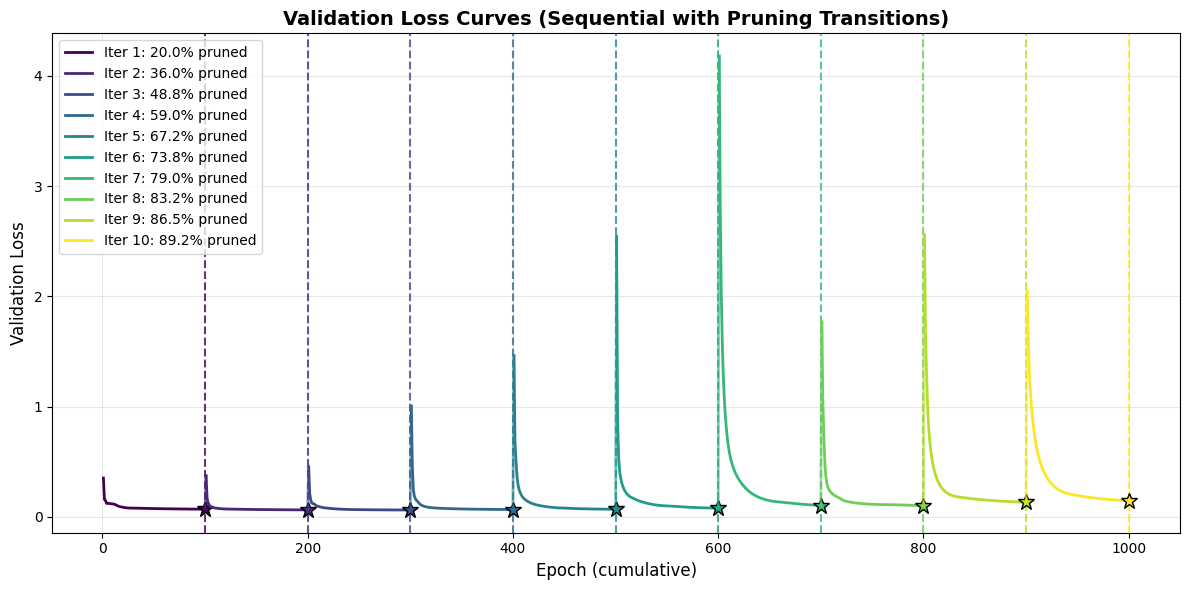

In [9]:
# Linearly prune the model
# Load the model
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

pntdnn_ideal_pruning_experiment = LinearExperiment(
    nn_model= pntdnn_ideal_predistorted,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    training_dataset=ideal_predistored_dataset.training_dataset,
    valid_dataset=ideal_predistored_dataset.validation_dataset,
    test_dataset=ideal_predistored_dataset.test_dataset,
    nmse_tolerance=-37
)
pntdnn_ideal_pruning_experiment.run()

# Save the best model
pntdnn_ideal_pruning_experiment.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")

Using cuda device
Baseline NMSE          : -37.0961 dB
Tolerance              : +0.10 dB
NMSE must stay below   : -37.0000 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 200 epochs...
Epoch  10/200  Loss=1.7482e+00  Valid Loss=1.7282e-01  LR=1.00e-03  NMSE=-35.7628 dB
Epoch  20/200  Loss=1.3759e+00  Valid Loss=1.3554e-01  LR=1.00e-03  NMSE=-36.8179 dB
Epoch  30/200  Loss=1.2634e+00  Valid Loss=1.1995e-01  LR=1.00e-03  NMSE=-37.3485 dB
Epoch  40/200  Loss=1.1845e+00  Valid Loss=1.1102e-01  LR=1.00e-03  NMSE=-37.6847 dB
Epoch  50/200  Loss=1.1189e+00  Valid Loss=1.0467e-01  LR=1.00e-03  NMSE=-37.9402 dB
Epoch  60/200  Loss=1.0645e+00  Valid Loss=9.9441e-02  LR=1.00e-03  NMSE=-38.1630 dB
Epoch  70/200  Loss=1.0158e+00  Valid Loss=9.4754e-02  LR=1.00e-03  NMSE=-38.3727 dB
Epoch  80/200  Loss=9.7548e-01  Valid Loss=9

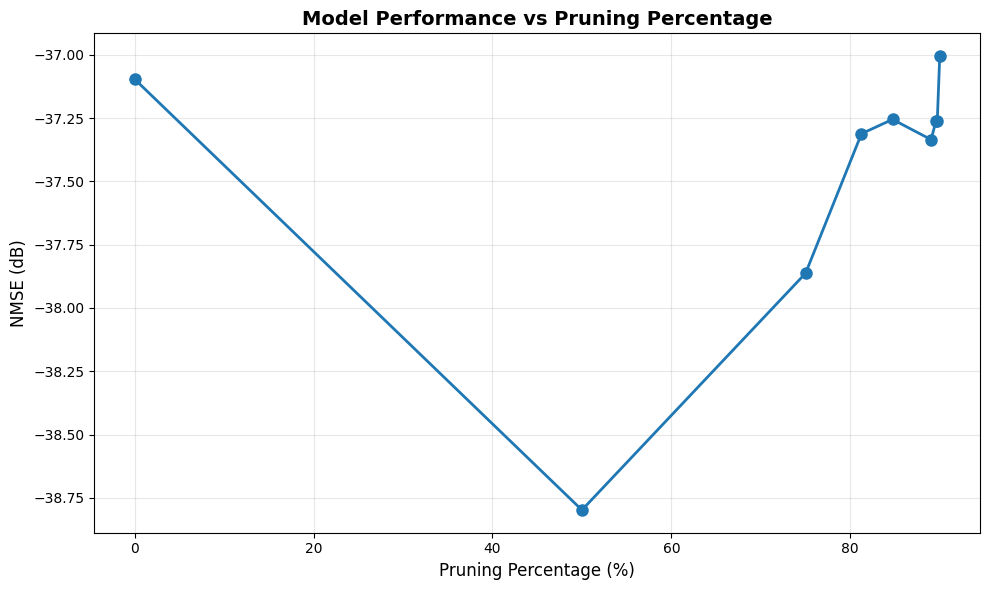

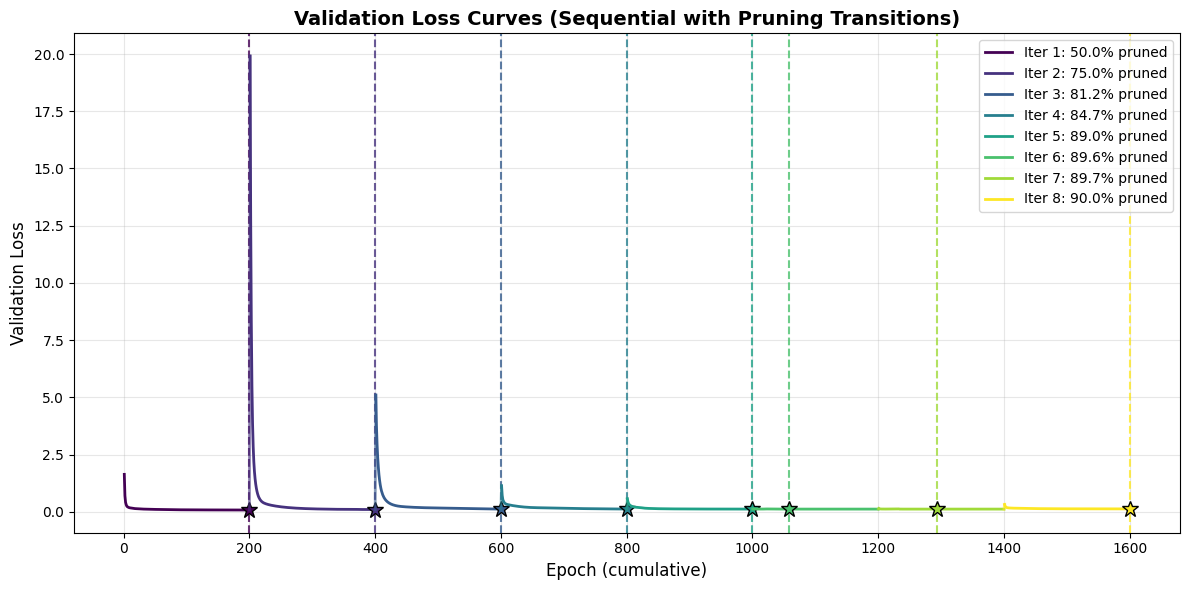

In [10]:
# Use adaptive pruning
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

adaptive_pruning_experiment_PNTDNN = AdaptivePruningExperiment(
    nn_model=pntdnn_ideal_predistorted,
    retrain_epochs= 200,
    training_dataset = ideal_predistored_dataset.training_dataset,
    valid_dataset = ideal_predistored_dataset.validation_dataset,
    test_dataset = ideal_predistored_dataset.test_dataset,
    nmse_threshold = -37,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment_PNTDNN.run()

# Save the best model
adaptive_pruning_experiment_PNTDNN.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")

In [ ]:
# make .mat files for the best models, so they can be used in the future for physical testing
import scipy.io

num_memory_levels = 15
# Load original, adaptive and fixed pruning models
adaptive_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")
fixed_percent_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")
original_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

# Get the full input signal
full_input = ideal_predistored_dataset.input_data

# Generate outputs for each model
print("Generating outputs for each model...")
adaptive_output = adaptive_model.generate_model_output(full_input)
fixed_output = fixed_percent_model.generate_model_output(full_input)
original_output = original_model.generate_model_output(full_input)

# Save to .mat files with 'x' (input) and 'u' (output) naming convention
print("Saving .mat files...")
scipy.io.savemat('adaptive_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': adaptive_output})
scipy.io.savemat('fixed_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': fixed_output})
scipy.io.savemat('original_model_output.mat', {'x1': full_input[num_memory_levels:], 'u': original_output})

print("✓ Saved adaptive_pruned_output.mat")
print("✓ Saved fixed_pruned_output.mat")
print("✓ Saved original_model_output.mat")

Using cuda device
Using cuda device
Using cuda device
Generating outputs for each model...
Saving .mat files...
✓ Saved adaptive_pruned_output.mat
✓ Saved fixed_pruned_output.mat
✓ Saved original_model_output.mat


In [ ]:
# Optionally save Volterra model output as well
volterra_output = volterra_forward_model.generate_model_output(full_input)
scipy.io.savemat('volterra_output.mat', {'x1': full_input[num_memory_levels:], 'u': volterra_output})
print("✓ Saved volterra_output.mat")

✓ Saved volterra_output.mat


In [22]:
test = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='adaptive_pruned_output.mat')

test.plot_pa_characteristics()

KeyError: "Could not find expected data columns in .mat file. Available keys: ['x', 'u1']"